In [60]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import TensorDataset, DataLoader, Dataset
from scipy.spatial.transform import Rotation

device = 'cuda'

In [56]:
def eval_model(model, metric, valid_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            
    return metric.compute()

def train_model(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs, 
                factor=0.5, patience=2, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor, patience)
    history = {'train_loss':[], 'train_metrics':[], 'valid_metrics':[]}
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        model.train()
        metric.reset()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
            
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f'\rBatch: {index + 1}/{len(train_loader)}', end="")
            print(f', loss={total_loss/(index+1):.3f}', end="")
            print(f', {train_metric=:.2f}', end="")
            
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_metrics'].append(train_metric)
        val_metric = eval_model(model, metric, valid_loader)
        history['valid_metrics'].append(val_metric)
        
        scheduler.step(val_metric)
        print(f'\rEpoch: {epoch+1}/{n_epochs}\tTrain loss: {history["train_loss"][-1]:.3f}\tTrain metrics: {history['train_metrics'][-1]:.3f}\tValid metrics: {history['valid_metrics'][-1]:.3f}')
    
    return history

In [ ]:
def generate_data(m, seed=52):
    X = np.zeros((m, 3))
    rng = np.random.default_rng(seed)
    angles = (rng.random(m)**3 + 0.5) * 2 * np.pi
    X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5
    X += 0.37 * rng.standard_normal((m, 3))
    X = Rotation.from_rotvec([np.pi / 29, -np.pi / 19, np.pi / 4]).apply(X)
    X += [0.23, 0, 0.23]
    return torch.from_numpy(X.astype(np.float32))

In [10]:
X_train = generate_data(60)
X_valid = generate_data(500)

X_train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=32, shuffle=True)
X_valid_loader = DataLoader(TensorDataset(X_valid, X_valid), batch_size=32)

In [17]:
encoder = nn.Linear(3, 2)
decoder = nn.Linear(2, 3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

optimizer = torch.optim.NAdam(autoencoder.parameters(), lr=0.2)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_model(autoencoder, optimizer, mse, rmse, X_train_loader, X_valid_loader, 50)

Epoch: 1/50	Train loss: 0.344	Train metrics: 0.589	Valid metrics: 0.545
Epoch: 2/50	Train loss: 0.204	Train metrics: 0.452	Valid metrics: 0.451
Epoch: 3/50	Train loss: 0.136	Train metrics: 0.370	Valid metrics: 0.432
Epoch: 4/50	Train loss: 0.149	Train metrics: 0.384	Valid metrics: 0.418
Epoch: 5/50	Train loss: 0.107	Train metrics: 0.330	Valid metrics: 0.315
Epoch: 6/50	Train loss: 0.069	Train metrics: 0.262	Valid metrics: 0.291
Epoch: 7/50	Train loss: 0.059	Train metrics: 0.243	Valid metrics: 0.266
Epoch: 8/50	Train loss: 0.053	Train metrics: 0.232	Valid metrics: 0.260
Epoch: 9/50	Train loss: 0.052	Train metrics: 0.228	Valid metrics: 0.255
Epoch: 10/50	Train loss: 0.051	Train metrics: 0.227	Valid metrics: 0.253
Epoch: 11/50	Train loss: 0.050	Train metrics: 0.224	Valid metrics: 0.252
Epoch: 12/50	Train loss: 0.050	Train metrics: 0.223	Valid metrics: 0.250
Epoch: 13/50	Train loss: 0.051	Train metrics: 0.222	Valid metrics: 0.250
Epoch: 14/50	Train loss: 0.049	Train metrics: 0.222	Valid me

## stacked autoencoders

In [70]:
encoder = nn.Sequential(nn.Flatten(), nn.Linear(1*28*28, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU())
decoder = nn.Sequential(nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 1*28*28), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
stacked_autoencoder = nn.Sequential(encoder, decoder).to(device)

In [ ]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
fashion_dataset = torchvision.datasets.FashionMNIST(root='/home/damian/test/ch10/datasets', train=True, transform=ToTensor)

fashion_train, fashion_valid = torch.utils.data.random_split(fashion_dataset, [55000, 5000])

In [52]:
fashion_valid_set = []
for el in fashion_valid:
    fashion_valid_set.append(torch.tensor(el[0], dtype=torch.float32))
fashion_valid_set = torch.stack(fashion_valid_set)

fashion_train_set = []
for el in fashion_train:
    fashion_train_set.append(torch.tensor(el[0], dtype=torch.float32))
fashion_train_set = torch.stack(fashion_train_set)

fashion_train_loader = DataLoader(TensorDataset(fashion_train_set, fashion_train_set), batch_size=32, shuffle=True)
fashion_valid_loader = DataLoader(TensorDataset(fashion_valid_set, fashion_valid_set), batch_size=32)

/tmp/ipykernel_6136/860554460.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fashion_valid_set.append(torch.tensor(el[0], dtype=torch.float32))
/tmp/ipykernel_6136/860554460.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fashion_train_set.append(torch.tensor(el[0], dtype=torch.float32))


In [71]:
optimizer = torch.optim.NAdam(stacked_autoencoder.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(stacked_autoencoder, optimizer, mse, rmse, fashion_train_loader, fashion_valid_loader, 20)

Epoch: 1/20	Train loss: 0.025	Train metrics: 0.158	Valid metrics: 0.143
Epoch: 2/20	Train loss: 0.020	Train metrics: 0.140	Valid metrics: 0.138
Epoch: 3/20	Train loss: 0.018	Train metrics: 0.136	Valid metrics: 0.140
Epoch: 4/20	Train loss: 0.018	Train metrics: 0.134	Valid metrics: 0.135
Epoch: 5/20	Train loss: 0.016	Train metrics: 0.125	Valid metrics: 0.124
Epoch: 6/20	Train loss: 0.015	Train metrics: 0.124	Valid metrics: 0.124
Epoch: 7/20	Train loss: 0.015	Train metrics: 0.123	Valid metrics: 0.123
Epoch: 8/20	Train loss: 0.014	Train metrics: 0.119	Valid metrics: 0.120
Epoch: 9/20	Train loss: 0.014	Train metrics: 0.119	Valid metrics: 0.119
Epoch: 10/20	Train loss: 0.014	Train metrics: 0.118	Valid metrics: 0.119
Epoch: 11/20	Train loss: 0.014	Train metrics: 0.116	Valid metrics: 0.117
Epoch: 12/20	Train loss: 0.013	Train metrics: 0.116	Valid metrics: 0.117
Epoch: 13/20	Train loss: 0.013	Train metrics: 0.116	Valid metrics: 0.117
Epoch: 14/20	Train loss: 0.013	Train metrics: 0.115	Valid me

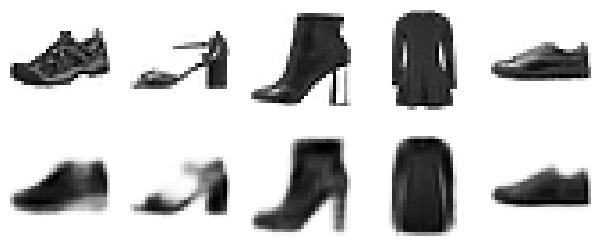

In [72]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap='binary')
    plt.axis('off')
    
def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
        
    fig = plt.figure(figsize=(len(images)*1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1+len(images)+idx)
        plot_image(y_pred[idx])
        
X_valid = fashion_valid_set[:10]
plot_reconstructions(stacked_autoencoder, X_valid)
plt.show()

anomaly detection using autoencoder (terrible reconstructions, big MSE loss proof)

/tmp/ipykernel_6136/3783836479.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  numbers_set.append(torch.tensor(el[0], dtype=torch.float32))


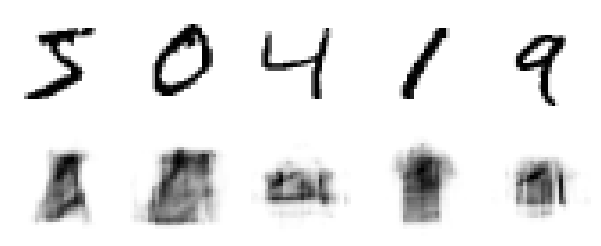

In [79]:
numbers_dataset = torchvision.datasets.MNIST(root='/home/damian/test/ch12/datasets', train=True, transform=ToTensor)

numbers_set = []
counter = 0
for el in numbers_dataset:
    numbers_set.append(torch.tensor(el[0], dtype=torch.float32))
    counter += 1
    if counter == 10:
        break
    
numbers_set = torch.stack(numbers_set)

plot_reconstructions(stacked_autoencoder, numbers_set)
plt.show()